# 425 ppm. ¿Es mucho?

Para saberlo necesitamos un termómetro de 3 millones de años.  
Un equipo lo encontró... congelado en la Antártida.

---

**Paper:** Marks Peterson, J. et al. (2025). *Broadly stable atmospheric CO₂ and CH₄ levels over the past 3 million years.* Nature.  
**DOI:** [10.1038/s41586-025-10032-y](https://doi.org/10.1038/s41586-025-10032-y)  
**Video:** [Ver en YouTube](https://youtube.com/shorts/OXIDk92qBKc) · [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-23-co2-estable-3-millones-anos/notebook.ipynb)

## El termómetro de hielo

En **Allan Hills** (76.7°S, 159.4°E), una zona remota de la Antártida, el hielo atrapa burbujas de aire de hace millones de años. Son cápsulas del tiempo atmosféricas: contienen la concentración exacta de CO₂ y metano del momento en que se formaron.

Un equipo perforó un núcleo de hielo de **3 millones de años** — el más antiguo jamás analizado para gases de efecto invernadero. Los datos están públicos. Vamos a verlos.

### ¿Dónde queda Allan Hills?

En el interior de la Antártida Oriental, a casi 2,000 metros de altitud. Es una **zona de hielo azul** — donde los vientos erosionan la superficie y exponen hielo antiguo que normalmente estaría enterrado a kilómetros de profundidad.

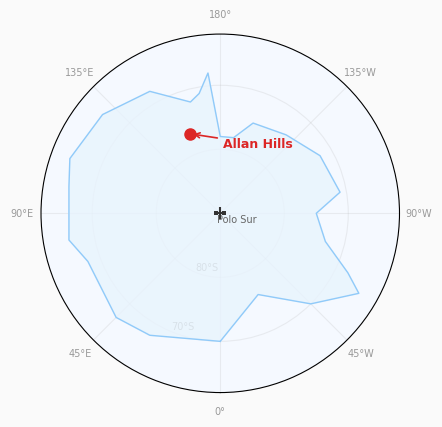

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(4.5, 4.5), subplot_kw={'projection': 'polar'})

# Proyección polar sur: theta=longitud, r=90+latitud (polo sur en centro)
# Línea de costa simplificada de la Antártida (puntos principales)
coast_lon = [0, 30, 45, 70, 80, 100, 110, 130, 150, 165, 170, 175, 180,
             -170, -160, -140, -120, -100, -90, -75, -65, -60, -45, -25, 0]
coast_lat = [-70, -68, -67, -68, -66, -66, -65, -66, -68, -72, -71, -68, -78,
             -78, -75, -74, -72, -71, -75, -73, -68, -65, -70, -76, -70]

coast_theta = np.radians(coast_lon)
coast_r = [90 + lat for lat in coast_lat]

# Dibujar continente
ax.fill(coast_theta, coast_r, color='#E8F4FD', alpha=0.8, zorder=2)
ax.plot(coast_theta, coast_r, color='#90CAF9', linewidth=1.0, zorder=3)

# Allan Hills: -76.73°S, 159.36°E
ah_theta = np.radians(159.356)
ah_r = 90 + (-76.732)
ax.plot(ah_theta, ah_r, 'o', color='#DC2626', markersize=8, zorder=5)
ax.annotate('Allan Hills', xy=(ah_theta, ah_r),
            xytext=(ah_theta + 0.4, ah_r - 3),
            fontsize=9, fontweight='bold', color='#DC2626',
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.2))

# Polo Sur
ax.plot(0, 0, '+', color='#333333', markersize=8, markeredgewidth=1.5, zorder=5)
ax.text(0.3, 1.5, 'Polo Sur', fontsize=7, color='#666666')

# Configuración
ax.set_rmax(28)  # Mostrar hasta ~62°S
ax.set_theta_zero_location('S')
ax.set_theta_direction(-1)
ax.set_rticks([10, 20])  # latitud 80°S, 70°S
ax.set_yticklabels(['80°S', '70°S'], fontsize=7, color='#999999')
ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(['0°', '45°E', '90°E', '135°E', '180°', '135°W', '90°W', '45°W'],
                   fontsize=7, color='#999999')
ax.grid(True, alpha=0.2)
ax.set_facecolor('#F5F9FF')
fig.patch.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('figuras/mapa_allan_hills.png', dpi=200, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

In [2]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CO2_ACTUAL = 425           # ppm (2025)
CO2_PREINDUSTRIAL = 280    # ppm
FUENTE = 'Fuente: Marks Peterson et al. (2025), Nature | Datos: USAP-DC'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os, urllib.request

# --- Descargar datos si no están locales (Colab, Binder) ---
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
archivos = {
    'datos/allan_hills_co2_ch4.csv': f'{BASE}/papers/2026-03-23-co2-estable-3-millones-anos/datos/allan_hills_co2_ch4.csv',
    'datos/edc_composite_co2.csv': f'{BASE}/papers/2026-03-23-co2-estable-3-millones-anos/datos/edc_composite_co2.csv',
}
for local, url in archivos.items():
    if not os.path.exists(local):
        urllib.request.urlretrieve(url, local)

# --- Cargar estilo CaM ---
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# --- Cargar datos ---
allan_hills = pd.read_csv('datos/allan_hills_co2_ch4.csv')
composite = pd.read_csv('datos/edc_composite_co2.csv')
pristine = allan_hills[allan_hills['excluded'] == 0].copy()

print(f'Allan Hills: {len(pristine)} muestras prístinas (de {len(allan_hills)} totales)')
print(f'Composite EDC: {len(composite)} puntos continuos')
print(f'Rango: {pristine["age_ka"].min():.0f} – {pristine["age_ka"].max():.0f} ka ({pristine["age_ka"].min()/1000:.1f} – {pristine["age_ka"].max()/1000:.1f} Ma)')
print(f'CO$_2$ promedio: {pristine["co2_mean_ppm"].dropna().mean():.0f} ppm | CO$_2$ actual: ~{CO2_ACTUAL} ppm')

Allan Hills: 83 muestras prístinas (de 158 totales)
Composite EDC: 1270 puntos continuos
Rango: 456 – 2868 ka (0.5 – 2.9 Ma)
CO$_2$ promedio: 242 ppm | CO$_2$ actual: ~425 ppm


## Tres millones de años de CO₂ en una gráfica

Aquí está.

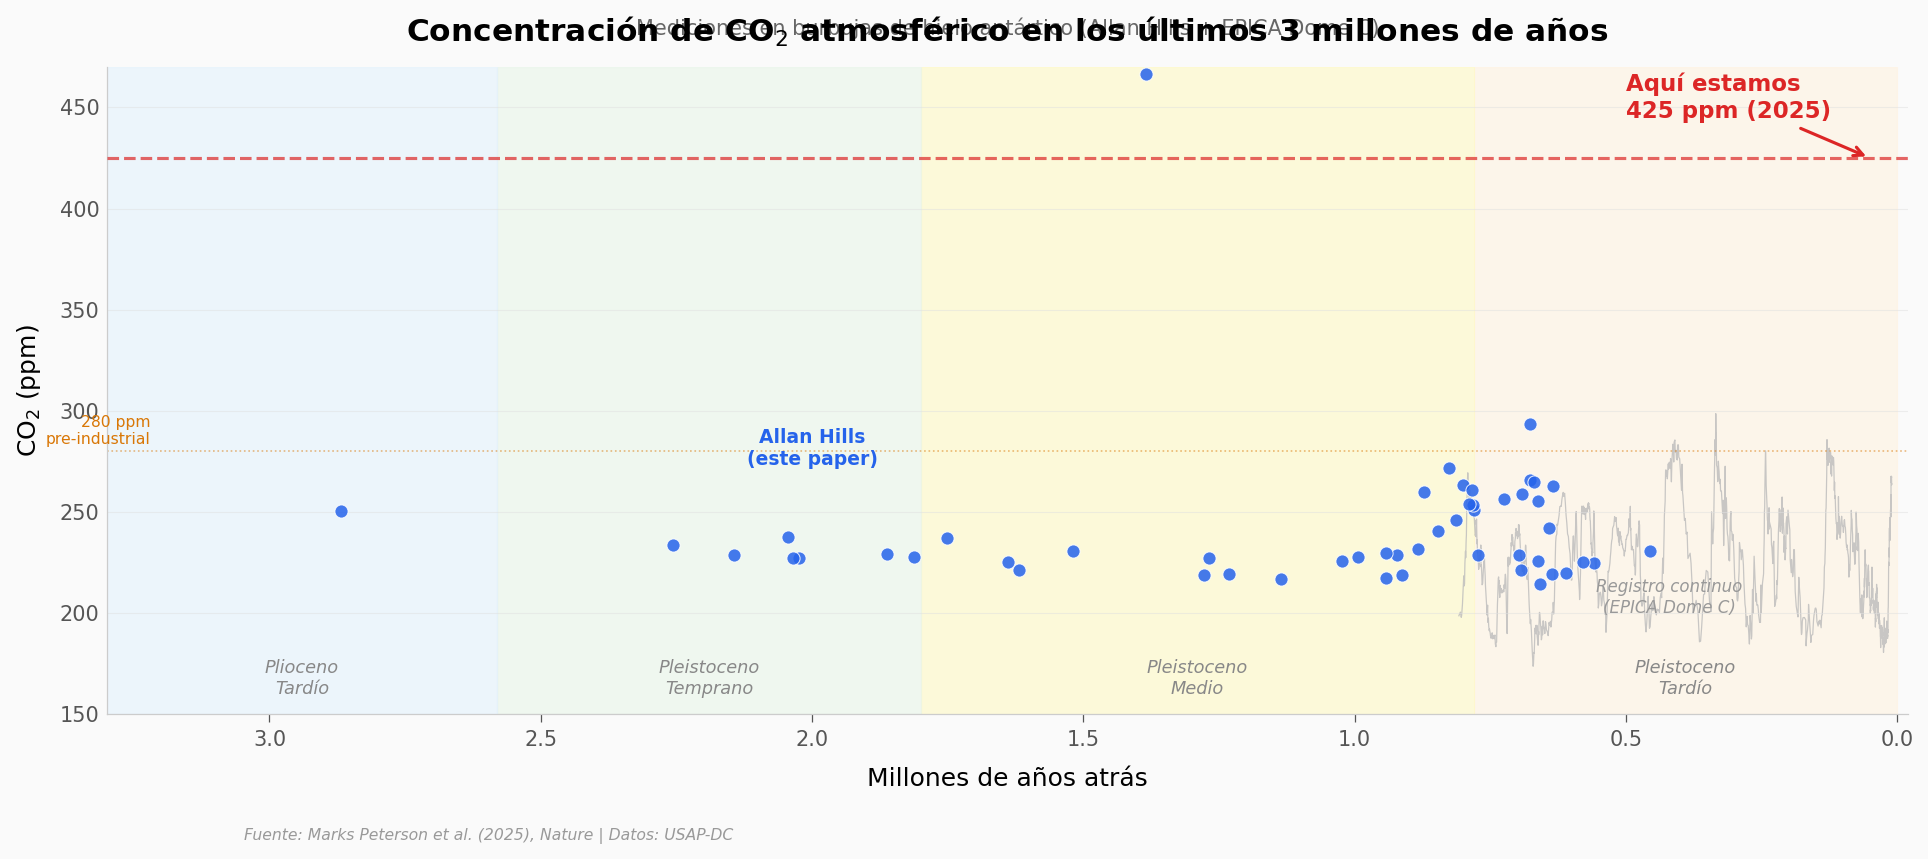

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# --- Bandas geológicas de fondo ---
epochs = [
    (0, 0.78, '#FFF3E0', 'Pleistoceno\nTardío'),
    (0.78, 1.8, '#FFF9C4', 'Pleistoceno\nMedio'),
    (1.8, 2.58, '#E8F5E9', 'Pleistoceno\nTemprano'),
    (2.58, 3.3, '#E3F2FD', 'Plioceno\nTardío'),
]
for start, end, color, label in epochs:
    ax.axvspan(start, end, color=color, alpha=0.6, zorder=0)
    ax.text((start + end) / 2, 158, label, ha='center', va='bottom',
            fontsize=8.5, color='#888888', style='italic')

# --- Composite EDC (registro continuo) ---
ax.plot(composite['age_ka'] / 1000, composite['co2_ppm'],
        color='#BBBBBB', linewidth=0.6, alpha=0.8, zorder=1)
ax.text(0.42, 200, 'Registro continuo\n(EPICA Dome C)', fontsize=8,
        color='#999999', ha='center', style='italic')

# --- Allan Hills (datos nuevos del paper) ---
ah = pristine.dropna(subset=['co2_mean_ppm'])
ax.scatter(ah['age_ka'] / 1000, ah['co2_mean_ppm'],
           color='#2563EB', s=40, alpha=0.85, zorder=5,
           edgecolors='white', linewidths=0.5)
ax.text(2.0, 273, 'Allan Hills\n(este paper)', fontsize=9,
        color='#2563EB', fontweight='bold', ha='center')

# --- Nivel pre-industrial ---
ax.axhline(y=CO2_PREINDUSTRIAL, color='#D97706', linewidth=0.8, linestyle=':', alpha=0.5, zorder=2)
ax.text(3.22, 282, f'{CO2_PREINDUSTRIAL} ppm\npre-industrial', fontsize=7.5,
        color='#D97706', va='bottom', ha='right')

# --- CO$_2$ actual con flecha ---
ax.axhline(y=CO2_ACTUAL, color='#DC2626', linewidth=1.5, linestyle='--', alpha=0.7, zorder=3)
ax.annotate(f'Aquí estamos\n{CO2_ACTUAL} ppm (2025)', xy=(0.05, 425),
            xytext=(0.5, 445), fontsize=11, fontweight='bold', color='#DC2626',
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.5),
            zorder=6)

# --- Configuración ---
ax.set_xlabel('Millones de años atrás', fontsize=12)
ax.set_ylabel('CO$_2$ (ppm)', fontsize=12)
ax.set_title('Concentración de CO$_2$ atmosférico en los últimos 3 millones de años',
             fontsize=15, fontweight='bold', pad=12)
ax.text(0.5, 1.05, 'Mediciones en burbujas de hielo antártico (Allan Hills + EPICA Dome C)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.02, 3.3)
ax.set_ylim(150, 470)
ax.invert_xaxis()

plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/co2_3_millones_anos.png', dpi=200, bbox_inches='tight')
plt.show()

Los puntos azules son mediciones de burbujas de aire atrapadas en hielo antártico de hasta 3 millones de años. La línea gris es el registro continuo conocido (EPICA Dome C, ~800,000 años). Y esa línea roja punteada que se sale del rango natural... es donde estamos hoy.

Durante **3 millones de años** — a través del Plioceno, las glaciaciones, la aparición del género *Homo* — el CO₂ osciló entre ~180 y ~280 ppm, con una media de **~240 ppm**. El registro continuo (EPICA) nunca superó 299 ppm.

> ⚠️ **Nota de transparencia:** Hay una muestra prístina a 467 ppm (a 1.38 Ma) que es probablemente un artefacto de medición — no tiene valor de CO₂ corregido y es un outlier extremo. La discutimos en la sección de verificación al final.

## La Tierra respirando

Esos dientes de sierra en el registro continuo son **ciclos glaciales** — la Tierra respirando cada ~100,000 años, gobernados por variaciones en su órbita ([ciclos de Milankovitch](https://es.wikipedia.org/wiki/Variaciones_orbitales)).

Hagamos zoom.

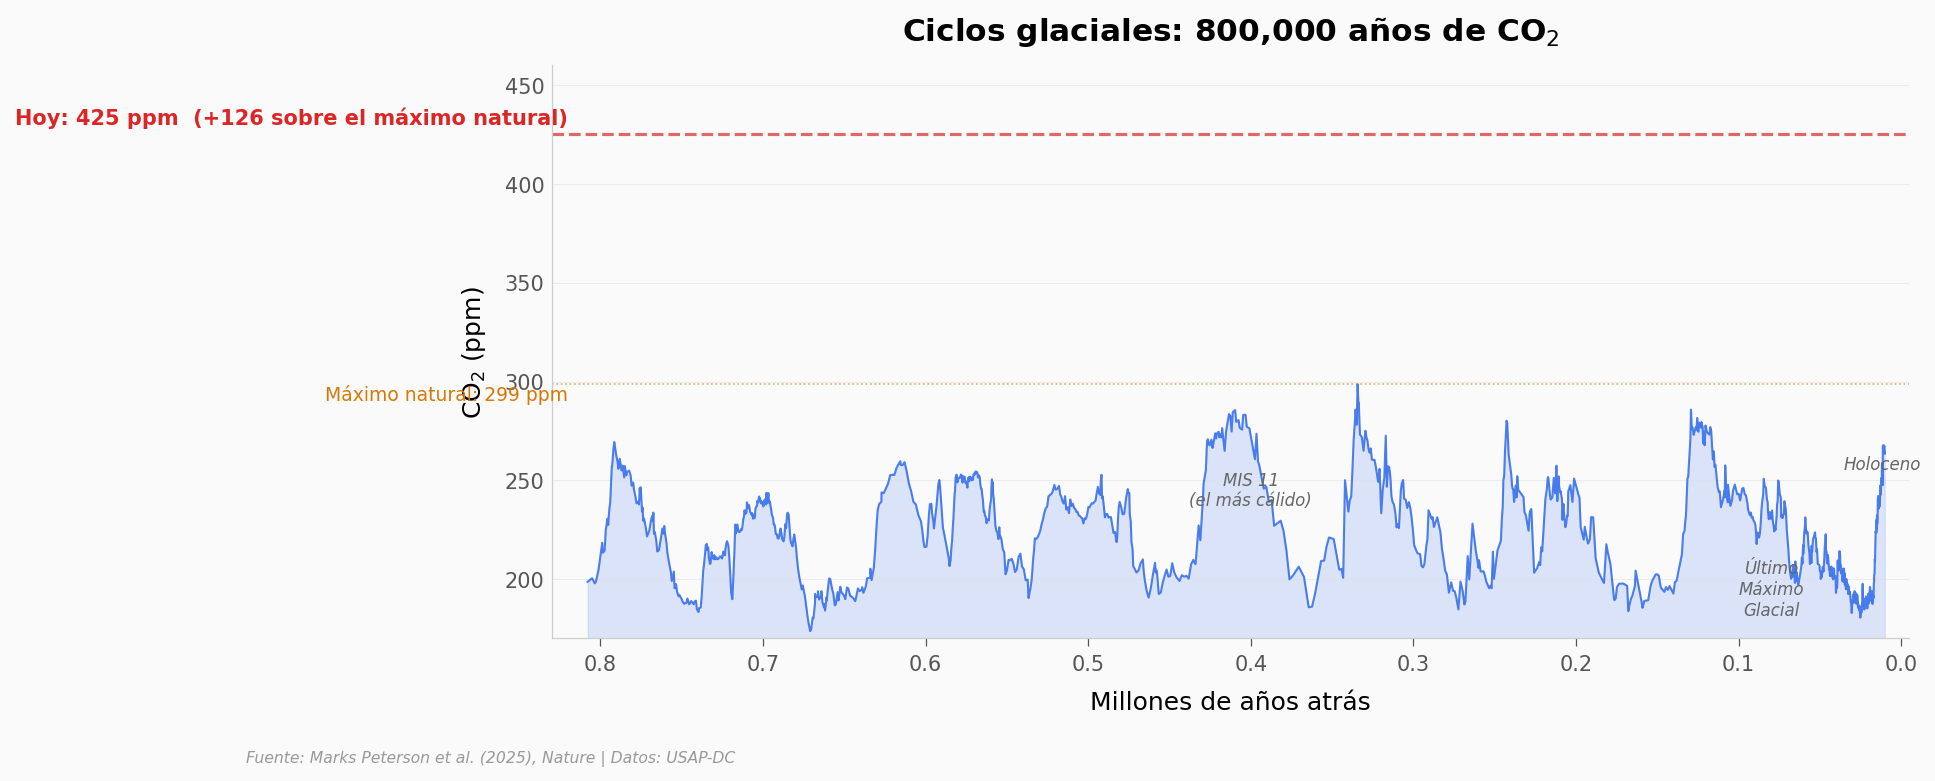

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

# Área bajo la curva
ax.fill_between(composite['age_ka'] / 1000, composite['co2_ppm'],
                alpha=0.15, color='#2563EB', zorder=1)
ax.plot(composite['age_ka'] / 1000, composite['co2_ppm'],
        color='#2563EB', linewidth=1.0, alpha=0.8, zorder=2)

# Máximo natural
co2_max = composite['co2_ppm'].max()
ax.axhline(y=co2_max, color='#D97706', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(0.82, co2_max - 8, f'Máximo natural: {co2_max:.0f} ppm',
        fontsize=9, color='#D97706', ha='right')

# CO$_2$ actual
ax.axhline(y=CO2_ACTUAL, color='#DC2626', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(0.82, 430, f'Hoy: {CO2_ACTUAL} ppm  (+{CO2_ACTUAL - co2_max:.0f} sobre el máximo natural)',
        fontsize=10, color='#DC2626', fontweight='bold', ha='right')

# Anotaciones de períodos
periods = [
    (0.012, 258, 'Holoceno'),
    (0.08, 195, 'Último\nMáximo\nGlacial'),
    (0.40, 245, 'MIS 11\n(el más cálido)'),
]
for x, y, txt in periods:
    ax.annotate(txt, xy=(x, y), fontsize=8, color='#666666',
                ha='center', va='center', style='italic')

ax.set_xlabel('Millones de años atrás', fontsize=12)
ax.set_ylabel('CO$_2$ (ppm)', fontsize=12)
ax.set_title('Ciclos glaciales: 800,000 años de CO$_2$', fontsize=15, fontweight='bold', pad=12)
ax.set_xlim(-0.005, 0.83)
ax.set_ylim(170, 460)
ax.invert_xaxis()

plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ciclos_glaciales_800ka.png', dpi=200, bbox_inches='tight')
plt.show()

Incluso en el interglacial más cálido de los últimos 800,000 años (MIS 11, hace ~400,000 años), el CO₂ no pasó de 300 ppm. El nivel actual está **126 ppm por encima** del máximo natural.

## El cómplice: metano

El CO₂ no actúa solo. El paper también midió **metano (CH₄)**, otro gas de efecto invernadero. ¿Se mueven juntos?

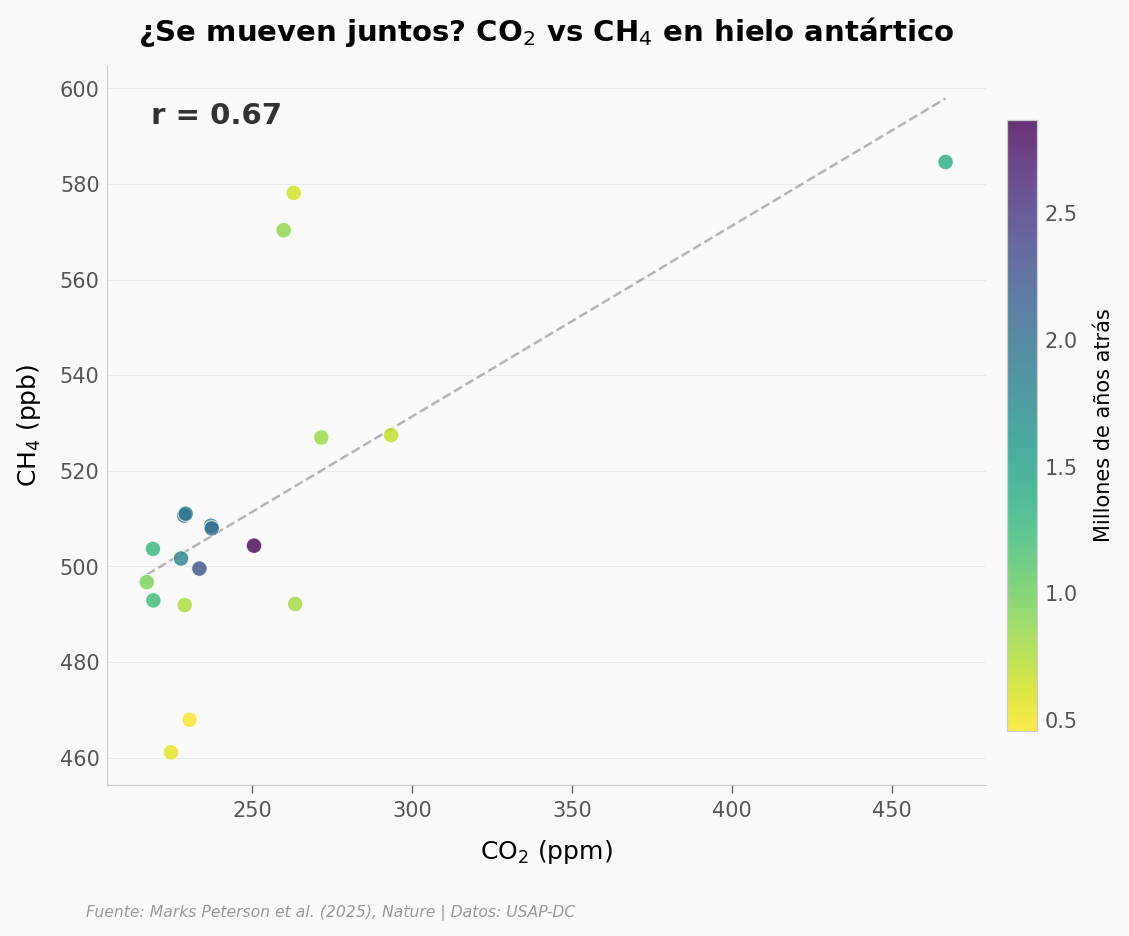

Correlación: r = 0.67 — cuando sube el CO$_2$, sube el CH$_4$.
El color muestra que esta relación se mantiene a lo largo de millones de años.


In [5]:
both = pristine.dropna(subset=['co2_mean_ppm', 'ch4_mean_ppb'])

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(both['co2_mean_ppm'], both['ch4_mean_ppb'],
                     c=both['age_ka'] / 1000, cmap='viridis_r',
                     s=55, alpha=0.8, edgecolors='white', linewidths=0.5, zorder=5)

# Línea de tendencia
z = np.polyfit(both['co2_mean_ppm'], both['ch4_mean_ppb'], 1)
p = np.poly1d(z)
x_line = np.linspace(both['co2_mean_ppm'].min(), both['co2_mean_ppm'].max(), 100)
ax.plot(x_line, p(x_line), color='#888888', linewidth=1.2, linestyle='--', alpha=0.6, zorder=3)

# Correlación
corr = both['co2_mean_ppm'].corr(both['ch4_mean_ppb'])
ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes,
        fontsize=14, fontweight='bold', va='top', color='#333333')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Millones de años atrás', fontsize=10)

ax.set_xlabel('CO$_2$ (ppm)', fontsize=12)
ax.set_ylabel('CH$_4$ (ppb)', fontsize=12)
ax.set_title('¿Se mueven juntos? CO$_2$ vs CH$_4$ en hielo antártico',
             fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
fig.text(0.08, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/co2_vs_ch4.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Correlación: r = {corr:.2f} — cuando sube el CO$_2$, sube el CH$_4$.')
print(f'El color muestra que esta relación se mantiene a lo largo de millones de años.')

Correlación **moderada** (r = 0.67, R² = 0.45) con solo **19 pares** de mediciones. Esto significa que el CO₂ explica ~45% de la variabilidad del CH₄ — la otra mitad responde a otros factores (ciclos orbitales, procesos oceánicos, permisos de medición).

¿Es suficiente para decir que "se mueven juntos"? Estadísticamente sí (p = 0.002), pero con cautela: la muestra es pequeña y la relación no es fuerte. En el registro continuo de EPICA (800 ka, miles de puntos), la correlación CO₂-CH₄ es mucho mayor (~0.8). La diferencia se explica porque Allan Hills son **instantáneas discretas**, no un registro continuo.

## ¿Qué tan anómalo es el CO₂ actual?

Hagamos la cuenta — pero con honestidad estadística.

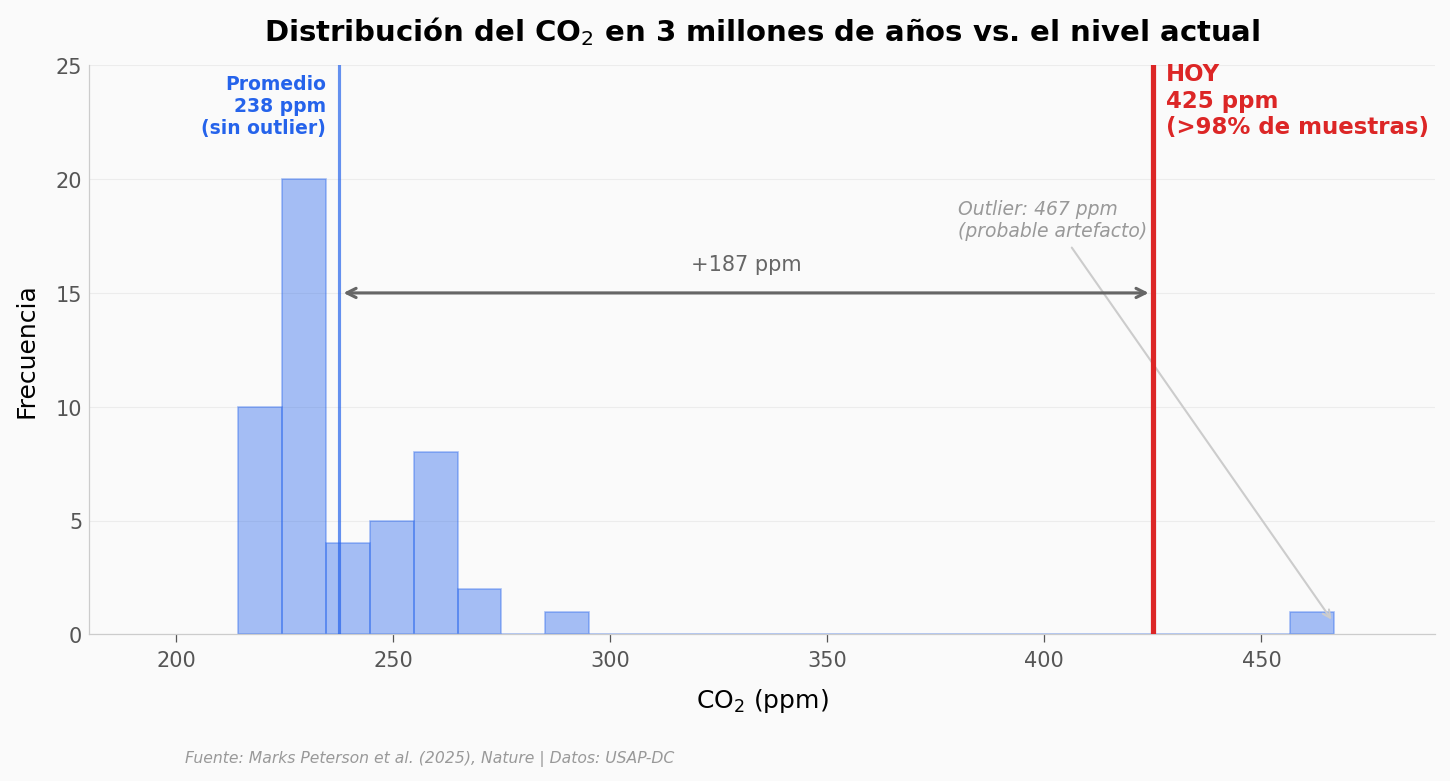

Con outlier:  media = 242.0 ± 36.7 ppm → 5.0σ
Sin outlier:  media = 237.6 ± 17.9 ppm → 10.5σ

⚠️  La distribución NO es normal (Shapiro-Wilk p ≈ 0), así que σ es orientativo.
Métrica robusta: el CO$_2$ actual (425 ppm) supera al 98% de todas las muestras de 3 Ma.

Incluso con el outlier de 467 ppm incluido, solo 1 de 51 muestras se acerca al nivel actual.


In [6]:
co2_data = pristine['co2_mean_ppm'].dropna()

# El outlier de 467 ppm infla la desviación estándar
# Mostramos ambas versiones: con y sin outlier
co2_clean = co2_data[co2_data <= 300]  # Sin el outlier extremo

media = co2_clean.mean()
std = co2_clean.std()
co2_actual = CO2_ACTUAL
percentil = (co2_data < co2_actual).mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))

# Histograma (todas las muestras)
n_hist, bins, patches = ax.hist(co2_data, bins=25, color=COLOR_DATOS, alpha=0.4,
                                edgecolor=COLOR_DATOS, linewidth=0.8, zorder=2)
y_max = n_hist.max() * 1.25
ax.set_ylim(0, y_max)

# Marcar el outlier
outlier_val = co2_data[co2_data > 300]
if len(outlier_val) > 0:
    ax.annotate(f'Outlier: {outlier_val.values[0]:.0f} ppm\n(probable artefacto)',
                xy=(outlier_val.values[0], 0.5), xytext=(380, y_max * 0.7),
                fontsize=9, color='#999999', style='italic',
                arrowprops=dict(arrowstyle='->', color='#CCCCCC', lw=1))

# Media (sin outlier)
ax.axvline(x=media, color=COLOR_DATOS, linewidth=1.5, linestyle='-', alpha=0.7, zorder=3)
ax.text(media - 3, y_max * 0.88, f'Promedio\n{media:.0f} ppm\n(sin outlier)',
        fontsize=9, color=COLOR_DATOS, fontweight='bold', ha='right')

# CO₂ actual
ax.axvline(x=co2_actual, color=COLOR_ALERTA, linewidth=2.5, linestyle='-', zorder=4)
ax.text(co2_actual + 3, y_max * 0.88,
        f'HOY\n{co2_actual} ppm\n(>{percentil:.0f}% de muestras)',
        fontsize=11, color=COLOR_ALERTA, fontweight='bold')

# Flecha
ax.annotate('', xy=(co2_actual, y_max * 0.6), xytext=(media, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + co2_actual) / 2, y_max * 0.64,
        f'+{co2_actual - media:.0f} ppm', ha='center', fontsize=10, color='#666666')

ax.set_xlabel('CO$_2$ (ppm)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del CO$_2$ en 3 millones de años vs. el nivel actual',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(180, 490)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_co2.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f'Con outlier:  media = {co2_data.mean():.1f} ± {co2_data.std():.1f} ppm → {(co2_actual - co2_data.mean()) / co2_data.std():.1f}σ')
print(f'Sin outlier:  media = {media:.1f} ± {std:.1f} ppm → {(co2_actual - media) / std:.1f}σ')
print(f'\n⚠️  La distribución NO es normal (Shapiro-Wilk p ≈ 0), así que σ es orientativo.')
print(f'Métrica robusta: el CO$_2$ actual ({co2_actual} ppm) supera al {percentil:.0f}% de todas las muestras de 3 Ma.')
print(f'\nIncluso con el outlier de 467 ppm incluido, solo 1 de {len(co2_data)} muestras se acerca al nivel actual.')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|--------|
| CO₂ fue estable ~240 ppm por 3 Ma | ✅ Sí | Media 238 ppm, CV 7.5% (sin outlier). "Estable" en escala geológica |
| El registro continuo nunca superó 300 ppm | ✅ Sí | Max composite EPICA = 299 ppm |
| CO₂ y CH₄ están acoplados | ⚠️ Parcial | r = 0.67 (moderado), R² = 0.45, pero solo n=19 pares. Estadísticamente significativo (p=0.002) pero muestra pequeña |
| CO₂ actual es "sin precedentes" | ✅ Sí | 425 ppm supera al 98% de muestras. Incluso el outlier (467 ppm) es probablemente un artefacto |
| El hielo cubre 3 millones de años | ✅ Sí | 456–2,868 ka. Son 51 puntos discretos (no continuo), pero el rango es ~3 Ma |

> **Limitaciones:** (1) Solo 51 mediciones de CO₂ en 3 Ma = una instantánea cada ~50,000 años. (2) 1 outlier a 467 ppm sin explicación clara. (3) Solo 19 pares CO₂-CH₄ para la correlación. (4) Los datos son de un solo sitio (Allan Hills) — no un registro global.

---

## Ahora tú

Los datos están cargados. Tres ideas para explorar:

1. **¿Y el Plioceno?** Hace 3 millones de años el clima era más cálido que hoy. ¿El CO₂ era más alto? Haz zoom a 2.5–3.2 Ma.
2. **El outlier.** La muestra a 467 ppm (1.38 Ma) — ¿cómo se compara con las excluidas? (`allan_hills[allan_hills['excluded'] == 1]`). ¿Debería haberse excluido?
3. **CO₂ corregido.** El dataset tiene `corrected_co2_ppm`. ¿Cambian las conclusiones con los valores corregidos?

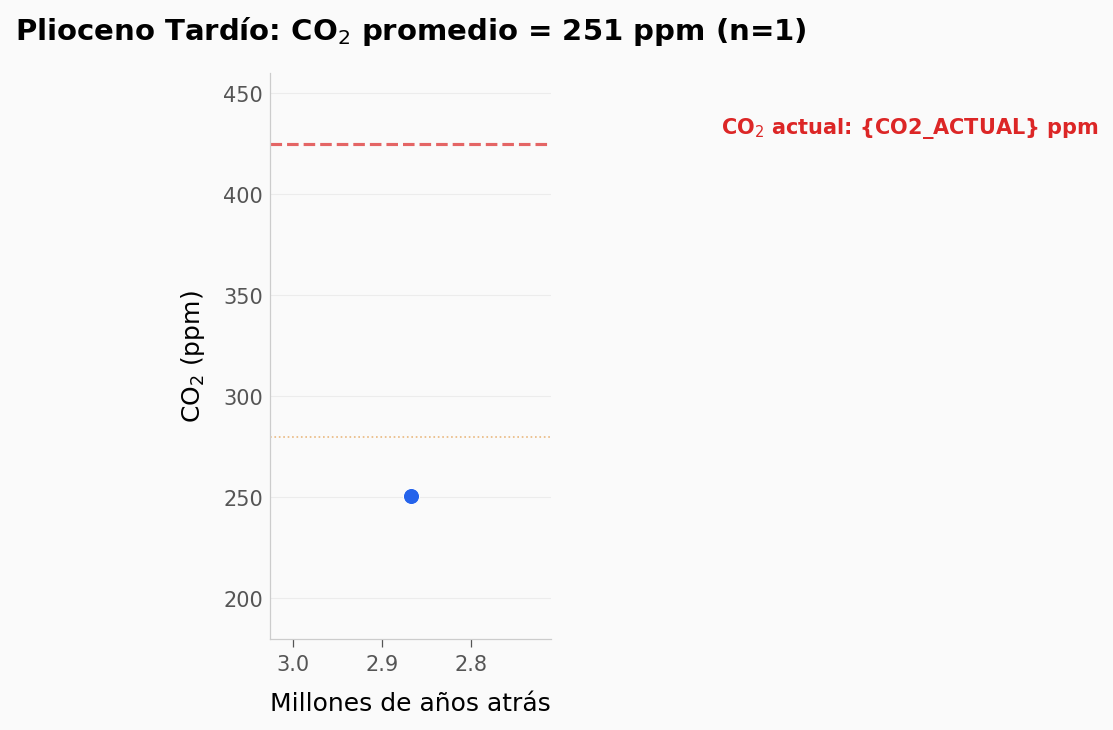

En el Plioceno Tardío (hace 2.5–3.2 Ma), cuando el clima era más cálido:
CO$_2$ = 251 ± nan ppm (1 muestras)
Incluso en un mundo más cálido, el CO$_2$ era 174 ppm MENOR que hoy.


In [7]:
# --- EXPERIMENTA AQUÍ ---

# Ejemplo: zoom al Plioceno (2.5 – 3.2 Ma)
plioceno = pristine[(pristine['age_ka'] >= 2500) & (pristine['age_ka'] <= 3200)]
plio_co2 = plioceno['co2_mean_ppm'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(plioceno['age_ka'] / 1000, plioceno['co2_mean_ppm'],
           color='#2563EB', s=60, edgecolors='white', linewidths=0.5, zorder=5)
ax.axhline(y=CO2_ACTUAL, color='#DC2626', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(2.52, 430, 'CO$_2$ actual: {CO2_ACTUAL} ppm', color='#DC2626', fontsize=10, fontweight='bold')
ax.axhline(y=280, color='#D97706', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xlabel('Millones de años atrás', fontsize=12)
ax.set_ylabel('CO$_2$ (ppm)', fontsize=12)
ax.set_title(f'Plioceno Tardío: CO$_2$ promedio = {plio_co2.mean():.0f} ppm (n={len(plio_co2)})',
             fontsize=14, fontweight='bold')
ax.set_ylim(180, 460)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

print(f'En el Plioceno Tardío (hace 2.5–3.2 Ma), cuando el clima era más cálido:')
print(f'CO$_2$ = {plio_co2.mean():.0f} ± {plio_co2.std():.0f} ppm ({len(plio_co2)} muestras)')
print(f'Incluso en un mundo más cálido, el CO$_2$ era {CO2_ACTUAL - plio_co2.mean():.0f} ppm MENOR que hoy.')

---

**Fuente de datos:** Marks Peterson, J. et al. (2025). Supplementary Materials, Nature. [DOI: 10.1038/s41586-025-10032-y](https://doi.org/10.1038/s41586-025-10032-y)  
**Datos originales:** US Antarctic Program Data Center. [DOI: 10.15784/601878](https://doi.org/10.15784/601878)  
**Licencia datos:** Supplementary Materials de Nature (acceso abierto).  
**Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC-BY 4.0